In [2]:
cd ..

/mnt/home/nzilberstein/CovarianceGeneralEDMScoreMatching


In [3]:
%load_ext autoreload
%autoreload 2

from noise import *
from pathlib import Path 
import json
from data import *
from trackers import *
from main import *

from covariance_generation import *

from networks.conditioning import *

import lpips
    
seed = 20
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
def load_args(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    return args_dict


def load_exp(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    args_dict['size_network'] = "large"

    ctx = TrainingContext(**args_dict, step=step, key_remap=None, seed=None, dataloaders=dataloaders, writer=False)
    if log:
        print(f"{name}: retrieved model at step {ctx.step}")

    # Disable DataParallel (needed for Hessian computation)
    # ctx.model.network = ctx.model.network.module

    # Put in eval mode and disable gradients with respect to all parameters.
    ctx.model.eval()
    for p in ctx.model.parameters():
        p.requires_grad = False

    # Normalize energies.
    # ctx.network.network.log_normalization_constant = ctx.test_perf.log_normalization_constant

    return ctx

def get_sigmas(sigma_begin, sigma_end, num_classes, device, sigma_dis):
    if sigma_dist == 'geometric':
        sigmas = torch.tensor(
            np.exp(np.linspace(np.log(sigma_begin), np.log(sigma_end),
                               num_classes))).float().to(device)
    elif sigma_dist == 'uniform':
        sigmas = torch.tensor(
            np.linspace(sigma_begin, sigma_end, num_classes)
        ).float().to(device)

    else:
        raise NotImplementedError('sigma distribution not supported')

    return sigmas

torch.set_default_dtype(torch.float32)
    # torch.set_printoptions(precision=10, sci_mode=False)

# args = load_args("multigpu/combined_cov_tworandvars/energy_song_anisoEmb_groupNorm_lambda0_lr1.5e-4_lrdecay15000_1000warmup_d2", step = "best")
args = load_args("multigpu/all_together/energy_song_dual_truncatedFreq_celeba", step = "best")
# args = load_args("multigpu/inpainting_celeba/energy_song_autoregressive_Celeba", step = "best")
# args = load_args("multigpu/combined_cov_tworandvars/energy_songWavelet_anisoEmb_groupNorm_lambda1_lr1.5e-4_lrdecay15000_1000warmup_d2", step = "last")
step = "last"
ctxs = {
            "Energy-Dual": load_exp("multigpu/all_together/energy_song_dual_truncatedFreq_celeba", step = step),
        }

default_ctx = ctxs["Energy-Dual"]
device = default_ctx.device
dataset_info = default_ctx.dataset_info
d = dataset_info.dimension


# Load data
test_batch_size = 20
H = 64
CHW = 3 * H * H

train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=test_batch_size, num_workers=8, seed=20
)

images = next(iter(test_dataloader))  # load for testing things.

shape = (images[0].shape[0], CHW)

time_tracker: TimeTracker = TimeTracker()
time_tracker.switch("initialization")


loss_fn_alex = lpips.LPIPS(net='alex').cuda() # best forward scores

False
multigpu/all_together/energy_song_dual_truncatedFreq_celeba: retrieved model at step 400000
Loading CelebA from train_64x64.pt...
✓ Loaded 182637 images with shape (182637, 64, 64, 3)
Loading CelebA from test_64x64.pt...
✓ Loaded 19962 images with shape (19962, 64, 64, 3)
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/lpips/weights/v0.1/alex.pth


In [32]:
# saved_outputs = torch.load("samples_posterior_0.pt")

# Sampling parameters
n_files = 21 #10
batch_size = 20 #32
path= "samples/imagenet_21_0.06_PC_adaptive"#"samples/Celeba_45_snr0.02_PC_freq"
# c
# # path_dps = "../CovarianceEDMScoreMatching/samples/Celeba_30_dps_freqsteps1200super_resolution" #"../CovarianceEDMScoreMatching/samples/Celeba_45_dps_freq"
# path_reddiff = "../CovarianceEDMScoreMatching/samples/ImageNet64_21_reddiff_pixel" #../CovarianceEDMScoreMatching/samples/Celeba_30_reddiff_freqsteps1200super_resolution" #"../CovarianceEDMScoreMatching/samples/Celeba_45_reddiff_freq"

# path = "samples/Celeba_45_0.06snr0.13box_45_1steps_PC_mala_pixel"#"samples/Celeba_45_snr0.02_PC_freq"
# path_dps = "samples/Celeba_45_0.06snr0.13box_45_5steps_PC_mala_pixel"
# # path_dps = "../CovarianceEDMScoreMatching/samples/Celeba_30_dps_freqsteps1200super_resolution" #"../CovarianceEDMScoreMatching/samples/Celeba_45_dps_freq"
# path_reddiff = "samples/Celeba_45_0.06snr0.13box_45_8steps_PC_mala_pixel" #../CovarianceEDMScoreMatching/samples/Celeba_30_reddiff_freqsteps1200super_resolution" #"../CovarianceEDMScoreMatching/samples/Celeba_45_reddiff_freq"

# path = "samples/Celeba_45_0.06_2"#"samples/Celeba_45_snr0.02_PC_freq"
# path_dps = "samples/Celeba_45_0.06snr0.13box_45_5steps_PC_pixel"
# # path_dps = "../CovarianceEDMScoreMatching/samples/Celeba_30_dps_freqsteps1200super_resolution" #"../CovarianceEDMScoreMatching/samples/Celeba_45_dps_freq"
# path_reddiff = "samples/Celeba_45_0.06snr0.13box_45_8steps_PC_pixel" #../CovarianceEDMScoreMatching/samples/Celeba_30_reddiff_freqsteps1200super_resolution" #"../CovarianceEDMScoreMatching/samples/Celeba_45_reddiff_freq"

# n_files = 10 #10
# batch_size = 32 #32
# path = "samples/Celeba_45_0.02posterior_exp10_PC_pixel"
# path_dps =  "../CovarianceEDMScoreMatching/samples/Celeba_45_dps_pixelposterior_exp10"
# path_reddiff = "../CovarianceEDMScoreMatching/samples/Celeba_45_reddiff_pixelposterior_exp10"
        

for bs in [n_files-1]:
    saved_outputs = torch.load(f"{path}/samples_posterior_{bs}.pt")
    y_ours = saved_outputs['y']# + 0.01 * torch.randn_like(saved_outputs['y'])
    x_hat = saved_outputs['samples']
    if path_dps is not None:
        saved_outputs_dps = torch.load(f"{path_dps}/samples_posterior_dps_{bs}_0.pt")
        x_mod_dps = saved_outputs_dps['samples']
    if path_reddiff is not None:
        saved_outputs_red = torch.load(f"{path_reddiff}/samples_posterior_{bs}.pt")
        x_mod_red = saved_outputs_red['samples']

# deblurring_id = sr_covariance_from_shape(spatial_size=64, kernel_size=4, device=device, noise_level=1)    #deblurring_covariance_from_shape(spatial_size=64, kernel_size=8, kernel_std=0.8, device=device, noise_level=1)
# # cov = deblurring_covariance_from_shape(spatial_size=img_size, kernel_size=kernel_size, kernel_std=kernel_std, device=device, noise_level=sigma_begin**2)

# for ii in range(y_ours.shape[0]):
#     y_ours[ii] = deblurring_id.apply_power(y_ours[ii], p = -0.5)

train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=20, num_workers=8, seed=20
)


for bs, images in enumerate(test_dataloader):
    x_true = images[0]

    if bs % (n_files - 1) == 0 and bs > 0:
        break

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00360132..1.0034575].


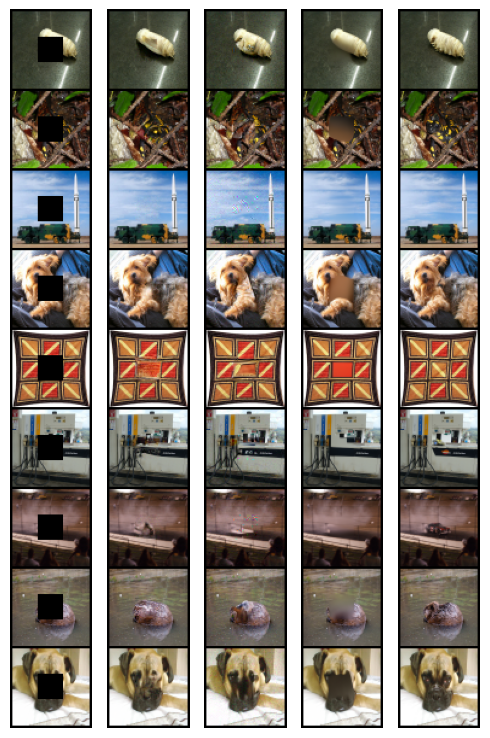

In [31]:
nrow = 1
idx_min = 0
idx_top = 10 + idx_min
grid = torchvision.utils.make_grid(y_ours[idx_min:idx_top], nrow=nrow, padding=2, normalize=False)
grid_y = grid.permute(1, 2, 0).cpu().numpy()
grid = torchvision.utils.make_grid(x_hat[idx_min:idx_top], nrow=nrow, padding=2, normalize=False)
grid_ours = grid.permute(1, 2, 0).numpy()
grid = torchvision.utils.make_grid(x_mod_dps[idx_min:idx_top], nrow=nrow, padding=2, normalize=False)
grid_dps = grid.permute(1, 2, 0).numpy()
grid = torchvision.utils.make_grid(x_mod_red[idx_min:idx_top], nrow=nrow, padding=2, normalize=False)
grid_red = grid.permute(1, 2, 0).numpy()
grid = torchvision.utils.make_grid(x_true[idx_min:idx_top], nrow=nrow, padding=2, normalize=False)
grid_true = grid.permute(1, 2, 0).numpy()


fig, ax = plt.subplots(1, 5, figsize = (5, 20))
ax[0].imshow(grid_y)
ax[1].imshow(grid_ours)
ax[2].imshow(grid_dps)
ax[3].imshow(grid_red)
ax[4].imshow(grid_true)
ax[0].axis("off")
ax[1].axis("off")
ax[2].axis("off")
ax[3].axis("off")
ax[4].axis("off")
# plt.show()
plt.tight_layout()
fig.savefig("imagenet.pdf", bbox_inches='tight', pad_inches=0.05)

In [139]:
train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=20, num_workers=8, seed=20
)


for bs, images in enumerate(test_dataloader):
    x_true = images[0]

    if bs % 9 == 0 and bs > 0:
        break

Loading CelebA from train_64x64.pt...
✓ Loaded 182637 images with shape (182637, 64, 64, 3)
Loading CelebA from test_64x64.pt...
✓ Loaded 19962 images with shape (19962, 64, 64, 3)


In [22]:
train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=test_batch_size, num_workers=8, seed=20
)


Loading CelebA from train_64x64.pt...
✓ Loaded 182637 images with shape (182637, 64, 64, 3)
Loading CelebA from test_64x64.pt...
✓ Loaded 19962 images with shape (19962, 64, 64, 3)


In [ ]:
from DISTS_pytorch import DISTS
D = DISTS()
# calculate DISTS between X, Y (a batch of RGB images, data range: 0~1)
# X: (N,C,H,W) 
# Y: (N,C,H,W) 
# dists_value = D(X, Y)

train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=False, data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=test_batch_size, num_workers=8, seed=20
)


n_files = 21 #10
batch_size = 20 #32
# path = "samples/ImageNet64_45_0.06snr0.02_PC_freq"#"samples/Celeba_45_snr0.02_PC_freq"
path = '../CovariancePalette/samples/Celeba_45_palette_pc_sampler_freq_wptfiles'
# path_dps = "samples/Celeba_45_0.06snr0.13dual_test_PC_mala_pixel"
# path_dps = "samples/Celeba_45_0.06snr0.08box_45_8steps_PC_mala_pixel" #"../CovarianceEDMScoreMatching/samples/Celeba_45_dps_freq"
# path_reddiff = "samples/Celeba_45_0.06" #"../CovarianceEDMScoreMatching/samples/Celeba_45_reddiff_freq"

# n_files = 10 #10
# batch_size = 32 #32
# path = "samples/Celeba_45_0.02posterior_exp10_PC_pixel"
# path_dps =  "../CovarianceEDMScoreMatching/samples/Celeba_45_dps_pixelposterior_exp10"
# path_reddiff = "../CovarianceEDMScoreMatching/samples/Celeba_45_reddiff_pixelposterior_exp10"
# loss_fn_alex = lpips.LPIPS(net='alex').cuda() # best forward scores        
mse = 0
lpips_ = 0
dists_value = 0
for bs, images in enumerate(test_dataloader):
    lpips_batch = 0
    saved_outputs = torch.load(f"{path}/samples_posterior_{bs}.pt")
    y_ours = saved_outputs['y']# + 0.01 * torch.randn_like(saved_outputs['y'])
    x_hat = saved_outputs['samples']

    x_hat = torch.clamp(x_hat, 0.0, 1.0)
    mse_batch = torch.mean((images[0] - x_hat)**2, dim=(-1, -2, -3)).sum() 
    for ii in range(batch_size):
        lpips_batch += loss_fn_alex(images[0][ii:ii+1].cuda(), x_hat[ii:ii+1].cuda())
    
    mse += mse_batch.item()
    lpips_ += lpips_batch.item()
    dists_value += D(images[0], x_hat).sum()

    print(bs)
    if n_files == 1:
        break
    else:
        if bs % (n_files-1) == 0 and bs > 0:
            break

print(10 * np.log10 (1 / (mse / ((n_files) * 20))), mse / ((n_files) * 20))
print(lpips_ / ((n_files) * 20))
print(dists_value / ((n_files) * 20))

Loading CelebA from train_64x64.pt...
✓ Loaded 182637 images with shape (182637, 64, 64, 3)
Loading CelebA from test_64x64.pt...
✓ Loaded 19962 images with shape (19962, 64, 64, 3)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [20]:
DPS -> 0.19
RED -> 0.17
Ours -> 0.14
DAPS -> 0.16

tensor([2.9865, 2.9948, 2.9453, 3.1511, 2.9649, 2.8758, 2.8319, 3.0534, 2.8946,
        2.6959, 3.2622, 2.9360, 3.0601, 2.7861, 2.9396, 3.0703, 2.7359, 3.0425,
        2.9828, 3.0068], grad_fn=<AddBackward0>)
